In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter   # для подсчёта частоты слов при построении словаря
import re                         # для простой очистки текста (регулярные выражения)
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# datasets — библиотека Hugging Face с готовыми датасетами, включая IMDB
%pip install datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Sarum\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
from datasets import load_dataset

# IMDB: 25 000 отзывов на train, 25 000 на test, сбалансирован по классам
# label: 0 = negative, 1 = positive
dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

print("\nПример отзыва:")
print(dataset['train'][0]['text'][:300])  # первые 300 символов, отзывы длинные
print("\nМетка (0=negative, 1=positive):", dataset['train'][0]['label'])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Пример отзыва:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

Метка (0=negative, 1=positive): 0


In [4]:
def tokenize(text):
    # приводим к нижнему регистру — "Movie" и "movie" должны быть одним токеном
    text = text.lower()
    # убираем HTML-теги, которые иногда встречаются в отзывах (например, <br />)
    text = re.sub(r'<.*?>', ' ', text)
    # оставляем только буквы и пробелы, остальное (знаки препинания, цифры) убираем
    text = re.sub(r'[^a-z\s]', ' ', text)
    # разбиваем строку на отдельные слова по пробелам
    tokens = text.split()
    return tokens

# проверим на примере
sample_text = dataset['train'][0]['text']
print(tokenize(sample_text)[:20])  # первые 20 токенов

['i', 'rented', 'i', 'am', 'curious', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it']


In [5]:
# считаем частоту каждого слова по всему train-датасету
counter = Counter()
for example in dataset['train']:
    counter.update(tokenize(example['text']))

print(f"Всего уникальных слов: {len(counter)}")
print("Самые частые слова:", counter.most_common(10))

Всего уникальных слов: 73267
Самые частые слова: [('the', 336757), ('and', 164136), ('a', 163172), ('of', 145866), ('to', 135721), ('is', 107336), ('it', 96472), ('in', 93980), ('i', 87685), ('this', 76006)]


In [7]:
# оставляем только слова, встретившиеся минимум min_freq раз —
# это отсекает опечатки, редкие имена и прочий "шум", а также сокращает размер модели
min_freq = 5

# сначала фильтруем слова по частоте
filtered_words = [word for word, freq in counter.items() if freq >= min_freq]

# и только затем нумеруем — так индексы будут идти подряд, без пропусков
vocab = {word: idx + 2 for idx, word in enumerate(filtered_words)}

# два служебных токена:
# <PAD> — используется для выравнивания длины отзывов внутри батча (добавляется "пустышками")
# <UNK> — заменяет любое слово, которого нет в словаре (в т.ч. редкие слова и слова из test, которых не было в train)
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

print(f"Размер словаря после фильтрации: {len(vocab)}")
print(f"Максимальный индекс в словаре: {max(vocab.values())}")

Размер словаря после фильтрации: 28771
Максимальный индекс в словаре: 28770


In [8]:
def text_to_sequence(text, vocab, max_len=200):
    tokens = tokenize(text)
    # для каждого токена берём его номер из словаря, а если слова нет — <UNK>
    sequence = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    
    # обрезаем слишком длинные отзывы и дополняем короткие нулями (<PAD>)
    # max_len нужен, чтобы все отзывы в батче были одинаковой длины — это требование тензоров
    if len(sequence) < max_len:
        sequence = sequence + [vocab['<PAD>']] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]
    
    return sequence

# проверим на примере
sample_sequence = text_to_sequence(dataset['train'][0]['text'], vocab)
print(f"Длина последовательности: {len(sample_sequence)}")
print(f"Первые 20 чисел: {sample_sequence[:20]}")

Длина последовательности: 200
Первые 20 чисел: [2, 3, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 18]


In [9]:
class IMDBDataset(Dataset):
    def __init__(self, hf_dataset, vocab, max_len=200):
        self.data = hf_dataset
        self.vocab = vocab
        self.max_len = max_len
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        text = self.data[idx]['text']
        label = self.data[idx]['label']
        
        sequence = text_to_sequence(text, self.vocab, self.max_len)
        
        # переводим в тензоры: последовательность чисел для LSTM,
        # метку — во float, т.к. будем использовать BCELoss (бинарная классификация)
        return torch.tensor(sequence, dtype=torch.long), torch.tensor(label, dtype=torch.float)

train_data = IMDBDataset(dataset['train'], vocab)
test_data = IMDBDataset(dataset['test'], vocab)

print(f"Train: {len(train_data)} объектов")
print(f"Test: {len(test_data)} объектов")

# проверим один объект
sample_seq, sample_label = train_data[0]
print(f"Форма последовательности: {sample_seq.shape}, метка: {sample_label}")

Train: 25000 объектов
Test: 25000 объектов
Форма последовательности: torch.Size([200]), метка: 0.0


In [10]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# проверим один батч
sequences, labels = next(iter(train_loader))
print(f"Размер батча последовательностей: {sequences.shape}")  # [32, 200]
print(f"Размер батча меток: {labels.shape}")                    # [32]

Размер батча последовательностей: torch.Size([32, 200])
Размер батча меток: torch.Size([32])


In [11]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128):
        super().__init__()
        
        # Embedding слой: превращает номер слова в плотный вектор заданной размерности,
        # эти векторы обучаются вместе со всей сетью (то, что мы разбирали в теории)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # LSTM: читает последовательность embedding-векторов по одному слову за раз,
        # batch_first=True значит, что форма входа [batch, seq_len, embedding_dim],
        # а не [seq_len, batch, embedding_dim] (так удобнее работать с нашими батчами)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        
        self.dropout = nn.Dropout(0.3)
        
        # финальный слой: берёт последнее скрытое состояние LSTM
        # и превращает его в одно число (вероятность положительного отзыва)
        self.fc = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        embedded = self.embedding(x)               # [batch, seq_len] -> [batch, seq_len, embedding_dim]
        
        # lstm_out содержит скрытые состояния на каждом шаге,
        # hidden — последнее скрытое состояние (то самое "общее впечатление" о предложении)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # hidden имеет форму [1, batch, hidden_dim] — убираем первую размерность
        hidden = hidden.squeeze(0)
        
        hidden = self.dropout(hidden)
        output = self.fc(hidden)                     # [batch, 1]
        return output.squeeze(1)                       # [batch] — убираем лишнюю размерность

vocab_size = len(vocab)
model = SentimentLSTM(vocab_size)
print(model)

SentimentLSTM(
  (embedding): Embedding(28771, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# BCEWithLogitsLoss объединяет сигмоиду и binary cross-entropy в одной операции —
# это численно стабильнее, чем делать sigmoid() вручную, а потом BCELoss отдельно
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Обучение на: {device}")
print(f"Размер словаря: {vocab_size}")

Обучение на: cpu
Размер словаря: 28771


In [13]:
num_epochs = 5  # для текста с LSTM обычно достаточно меньше эпох, чем для изображений —
                 # переобучение наступает быстрее из-за большого числа параметров embedding-слоя
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # --- фаза обучения ---
    model.train()
    running_loss = 0.0
    for sequences, labels in train_loader:
        sequences, labels = sequences.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(sequences)             # forward pass
        loss = criterion(outputs, labels)
        loss.backward()                         # backpropagation через все шаги LSTM
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- фаза проверки ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for sequences, labels in test_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Эпоха {epoch+1}/{num_epochs}: train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}")

Эпоха 1/5: train_loss=0.6904, val_loss=0.6801
Эпоха 2/5: train_loss=0.6766, val_loss=0.6935
Эпоха 3/5: train_loss=0.6551, val_loss=0.5381
Эпоха 4/5: train_loss=0.3741, val_loss=0.3840
Эпоха 5/5: train_loss=0.2432, val_loss=0.3711


In [14]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for sequences, labels in test_loader:
        sequences, labels = sequences.to(device), labels.to(device)
        outputs = model(sequences)
        # применяем сигмоиду вручную, т.к. модель выдаёт "сырые" логиты (без активации)
        probs = torch.sigmoid(outputs)
        # порог 0.5: если вероятность > 0.5, считаем класс положительным (1)
        preds = (probs > 0.5).float()
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
print(f"Test accuracy: {accuracy:.4f}")
print(f"Test F1: {f1:.4f}")

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=['negative', 'positive']))

Test accuracy: 0.8402
Test F1: 0.8392

Classification report:
              precision    recall  f1-score   support

    negative       0.84      0.85      0.84     12500
    positive       0.84      0.83      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



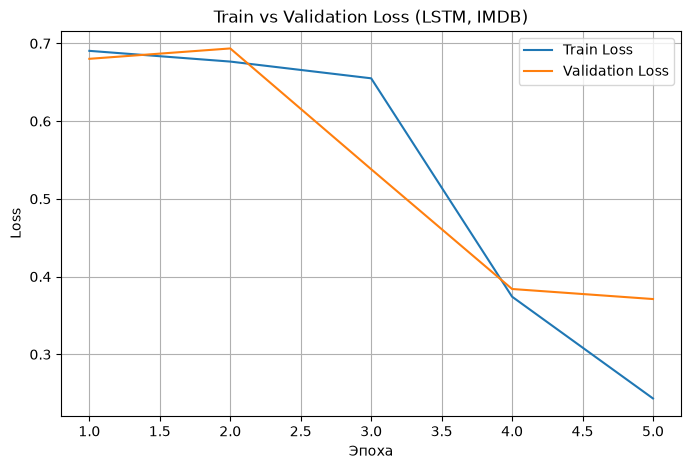

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss (LSTM, IMDB)')
plt.legend()
plt.grid(True)
plt.savefig('images/loss_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
wrong_indices = np.where(all_preds != all_labels)[0]

print(f"Всего ошибок: {len(wrong_indices)} из {len(all_labels)}")

# покажем 3 примера ошибок с текстом отзыва
for idx in wrong_indices[:3]:
    true_label = 'positive' if all_labels[idx] == 1 else 'negative'
    pred_label = 'positive' if all_preds[idx] == 1 else 'negative'
    text = dataset['test'][int(idx)]['text']
    print(f"\n--- Правда: {true_label}, Предсказано: {pred_label} ---")
    print(text[:250], "...")

Всего ошибок: 3994 из 25000

--- Правда: negative, Предсказано: positive ---
I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prost ...

--- Правда: negative, Предсказано: positive ---
First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy these kinds of movies for what they are. This movie is ...

--- Правда: negative, Предсказано: positive ---
I had high hopes for this one until they changed the name to 'The Shepherd : Border Patrol, the lamest movie name ever, what was wrong with just 'The Shepherd'. This is a by the numbers action flick that tips its hat at many classic Van Damme films.  ...
